In [1]:
import sys
import time
import h5py
import torch
import math
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# Basic pytorch setup

In [2]:
# Connect torch to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)

cuda


In [3]:
# Load test set
f = h5py.File('../data/sdr_wifi_test.hdf5', 'r')
X_test = f['X'][()]
y_test = f['y'][()]
f.close()

# Load train set
f = h5py.File('../data/sdr_wifi_train.hdf5', 'r')
X_train = f['X'][()]
y_train = f['y'][()]
f.close()

# Description of input variables

- `sequence_length` is the amount of IQ samples is in a single sample of data
- `num_channels` is the amount of number each IQ samples consists of (2)
- `hidden_size` is the amount of layers the LSTM will use
- `num_layers` is the amount of hidden layers that perform changes to get the correct prediction (chosen based on https://stats.stackexchange.com/questions/181/how-to-choose-the-number-of-hidden-layers-and-nodes-in-a-feedforward-neural-netw)
- `output_size` is the amount of frequencies that are predicted, these are equal to the input since we want to see from the full prediction which frequency most likely has the lowest interference
- `num_epochs` is the amount of training rounds
- `learning_rate` is the rate at which the weights of the hidden layers are updated to improve prediction results (cannot be too high because it might overshoot)


In [4]:
data = torch.FloatTensor(X_train).to(device)
labels = torch.FloatTensor(y_train).to(device)

print(data.shape)
print(labels.shape)

# Neural network input
sequence_length = data.shape[1]
num_channels = data.shape[2]
hidden_size = 48
num_layers = 1
output_size = labels.shape[1]

learning_rate = 1e-3
num_epochs = 20
batch_size = 128

torch.Size([1439971, 256, 2])
torch.Size([1439971, 4])


In [5]:
USE_LOGITS = True

In [6]:
class ConvLSTMModel(nn.Module):
    def __init__(self, sequence_length, num_channels = 2, output_size = 4, hidden_size = 32):
        super(ConvLSTMModel, self).__init__()

        # input shape: (batch_size, sequence_length, num_channels)
        # in this instance this is (batch_size, 256, 2)

        # Convolutional layers
        ## Change (batch_size, 2, 256) to (batch_size, 16, 256)
        self.conv1 = nn.Conv1d(in_channels=num_channels, out_channels=16, kernel_size=3, stride=1, padding=1)
        ## Change (batch_size, 16, 256) to (batch_size, 32, 256)
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)

        # Pooling layer 
        ## Change (batch_size, 32, 256) to (batch_size, 32, 128)
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)

        # LSTM layer
        ## Change (batch_size, 32, 128) to (batch_size, 4, 1)
        self.lstm = nn.LSTM(input_size=32, hidden_size=hidden_size, num_layers=1, batch_first=True)

        # Fully connected output layer
        self.fc = nn.Linear(
            in_features=hidden_size,
            out_features=output_size
        )

    def forward(self, x):
        # Step 1: get more information out of the IQ samples using convolution
        # Input shape: [batch_size, sequence_length, 2]
        x = x.permute(0, 2, 1) # -> [batch_size, 2, sequence_length]

        # First convolutional layer
        x = self.conv1(x) # -> [batch_size, 16, sequence_length]
        x = torch.relu(x) # -> [batch_size, 16, sequence_length]

        # Second convolutional layer
        x = self.conv2(x) # -> [batch_size, 32, sequence_length]
        x = torch.relu(x) # -> [batch_size, 32, sequence_length]

        # Pooling layer (tested to improve result)
        x = self.pool(x) # -> [batch_size, 32, sequence_length // 2]

        # Step 2: pass through LSTM
        x = x.permute(0, 2, 1) # -> [batch_size, sequence_length // 2, 32]

        # Pass through LSTM
        lstm_out, _ = self.lstm(x)  # -> [batch_size, sequence_length // 2, hidden_size]

        # Use the last LSTM output
        x = lstm_out[:, -1, :]  # -> [batch_size, hidden_size]

        # Fully connected layer
        x = self.fc(x) # -> [batch_size, output_size]

        if not USE_LOGITS:
            x = torch.sigmoid(x)

        return x

# Initialize the model, loss function, and optimizer
model = ConvLSTMModel(
    sequence_length=sequence_length,
    num_channels=num_channels,
    output_size=output_size,
    hidden_size=hidden_size
).to(device)
criterion = nn.BCEWithLogitsLoss() if USE_LOGITS else nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

In [7]:
dataset = TensorDataset(data, labels)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

loss_history = []
avg_loss = 0

start_time = time.time()

# Training loop
for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for i, (x_batch, y_batch) in enumerate(train_loader):
        # Forward pass
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        sys.stdout.write(f"\rEpoch [{epoch + 1}/{num_epochs}] | ({i} / {math.floor(len(data) / batch_size)}) | Loss: {loss.item():.4f} | Avg Loss last epoch: {avg_loss:.4f}")

    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)

    # Step the scheduler
    scheduler.step()

end_time = time.time()

training_time = end_time - start_time

Epoch [20/20] | (11249 / 11249) | Loss: 0.0483 | Avg Loss last epoch: 0.0515

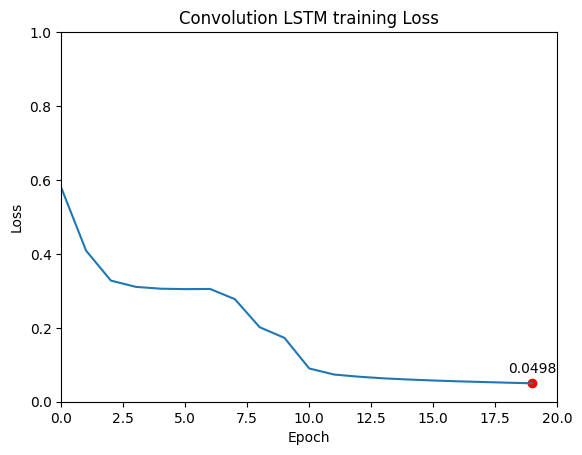

In [8]:
# Evaluate the model
plt.plot(loss_history)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Convolution LSTM training Loss')

plt.xlim(0, num_epochs)
plt.ylim(0, 1)

last_x = len(loss_history) - 1
last_y = loss_history[-1]
plt.scatter(last_x, last_y, color='red')
plt.text(last_x - 1, last_y + 0.02, f'{last_y:.4f}', verticalalignment='bottom')

plt.savefig('../docs/results/conv_lstm_loss.png')
plt.show()

In [9]:
model.eval()
with torch.no_grad():
    total_loss = 0
    correct_predictions = 0
    total_samples = 0

    for i in range(0, len(X_test), batch_size):
        X_batch = torch.FloatTensor(X_test[i:i+batch_size]).to(device)
        y_batch = torch.FloatTensor(y_test[i:i+batch_size]).to(device)

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        total_loss += loss.item()

        # Convert probabilities to binary predictions
        predicted = (outputs > 0.5).float()

        # Calculate the number of correct predictions
        correct_predictions += (predicted == y_batch).sum().item()
        total_samples += y_batch.numel()

        sys.stdout.write(f"\rTest Loss: {loss.item():.4f}")

    accuracy = correct_predictions / total_samples
    print(f"\nTotal Test Loss: {total_loss}")
    print(f"Test Accuracy: {accuracy:.4f}")

print("\nDone!")

Test Loss: 0.0528
Total Test Loss: 58.318497981876135
Test Accuracy: 0.9761

Done!


In [10]:
import pandas as pd

# Make a prediction based on the last sample
model.eval()

results = []

with torch.no_grad():
    for i in range(100):
        X_sample = torch.FloatTensor(X_test[i]).to(device)
        
        # Change shape from (256, 2) to (1, 256, 2)
        X_sample = X_sample.unsqueeze(0)

        time_start = time.time()

        output = model(X_sample)

        time_end = time.time()

        predicted = (output > 0).float()
        results.append({
            'index': i,
            'predicted': predicted.tolist()[0],
            'actual': y_test[i].tolist(),
            'output': output,
            'time': (time_end - time_start) * 1000,
            'total_accuracy': accuracy
        })

results_df = pd.DataFrame(results)
results_df.to_csv('../docs/results/conv_lstm.csv', index=False)

In [11]:
accuracy_df = pd.read_csv('../docs/results/accuracy.csv')

accuracy_df = accuracy_df[accuracy_df['model'] != 'conv_lstm']
accuracy_df = pd.concat([accuracy_df, pd.DataFrame([{
    'model': 'conv_lstm',
    'label': 'Convolutional LSTM model',
    'accuracy': accuracy * 100,
    'training_time': training_time,
    'epochs': num_epochs,
    'avg_response_time': results_df['time'].mean(),
    'avg_loss': avg_loss
}])])
accuracy_df.to_csv('../docs/results/accuracy.csv', index=False)